# LSTM behavior analysis (XAI + tests)

Run **after** `hourly.ipynb` and/or `15min.ipynb` (models must be on Drive).

This notebook:
1. Computes **SHAP** and **Integrated Gradients (IG)** for **every saved model**
2. Runs **behavior tests** on those explanations (memory erasure, fidelity, etc.)

Outputs go to `Final/{track}/behaviors/` (separate from `analysis.ipynb`).

Set `FORCE_RECOMPUTE = True` only if you want to redo everything.

In [ ]:
FORCE_RECOMPUTE = False
test_ratio = 0.18

TRACKS = ["hourly", "15min"]
STACKS = ["single", "double", "bidir"]
WINDOWS = {
    "hourly": [1, 4, 8, 12, 16, 24, 36, 48, 74, 168, 336, 672],
    "15min": [1, 4, 8, 16, 24, 48, 64, 96, 672],
}

# quick test: WINDOWS = {"hourly": [8, 24], "15min": [8, 24]}

COMPARE_WINDOW = 24   # used in architecture comparison (hourly win24 = 24 hours)
ERASE_CUTOFFS = [0.0, 0.25, 0.5, 0.75]
IG_SAMPLES = 20
FIDELITY_TOP_K = 2

DRIVE_BASE = "/content/drive/MyDrive/Shared-Colab-Storage"
ROOT = f"{DRIVE_BASE}/Final"

## Setup (Colab)

In [2]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow shap

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model


def rmse_metric(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_true - y_pred)))


def build_windows(scaled_df, feature_cols, window, test_ratio=0.18):
    arr = scaled_df[feature_cols].to_numpy(dtype=np.float32)
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window])
        y.append(arr[i + window, 0])
    X, y = np.array(X), np.array(y)
    split = int(len(X) * (1 - test_ratio))
    return X[:split], X[split:], y[:split], y[split:]


def to_kwh(vals, scaler, n_features, target_idx=0):
    vals = np.asarray(vals).ravel()
    d = np.zeros((len(vals), n_features))
    d[:, target_idx] = vals
    return scaler.inverse_transform(d)[:, target_idx]


def integrated_gradients(model, x, baseline, steps=50):
    x_t = tf.convert_to_tensor(x[np.newaxis, ...], dtype=tf.float32)
    b_t = tf.convert_to_tensor(baseline[np.newaxis, ...], dtype=tf.float32)
    grads_sum = tf.zeros_like(x_t)
    for alpha in tf.linspace(0.0, 1.0, steps + 1):
        with tf.GradientTape() as tape:
            interp = b_t + alpha * (x_t - b_t)
            tape.watch(interp)
            pred = model(interp, training=False)
        grads_sum += tape.gradient(pred, interp)
    return ((x_t - b_t) * (grads_sum / float(steps + 1))).numpy()[0]

## Load preprocessed data from Drive

We reuse `data.csv` and `scaler.pkl` saved by the training notebooks.

In [4]:
track_data = {}

for track in TRACKS:
    base = f"{ROOT}/{track}"
    data_csv = f"{base}/data.csv"
    scaler_pkl = f"{base}/scaler.pkl"
    if not os.path.exists(data_csv):
        print(f"Skip {track}: run {track}.ipynb first")
        continue
    scaled_df = pd.read_csv(data_csv)
    with open(scaler_pkl, "rb") as f:
        scaler = pickle.load(f)
    feature_cols = list(scaled_df.columns)
    os.makedirs(f"{base}/behaviors", exist_ok=True)
    track_data[track] = {
        "base": base,
        "scaled_df": scaled_df,
        "scaler": scaler,
        "feature_cols": feature_cols,
    }
    print(track, "loaded:", scaled_df.shape, "features:", feature_cols)

hourly loaded: (8760, 10) features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Load_Type', 'Day_of_week']
15min loaded: (35040, 10) features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


---
# Part 1 — SHAP (feature importance)

**Question:** Which input features matter most for the prediction?

**Method:** SHAP measures how much each feature changes the output.

**How to read:** Higher bar = model relies more on that feature. We expect `Usage_kWh` (past energy) to rank high.

Runs for **every** saved model (single / double / bidir × all window sizes).

In [5]:
for track, info in track_data.items():
    base = info["base"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    out_root = f"{base}/behaviors/shap"

    for stack in STACKS:
        for window in WINDOWS[track]:
            model_path = f"{base}/{stack}/models/win{window}.keras"
            if not os.path.exists(model_path):
                continue

            os.makedirs(f"{out_root}/{stack}", exist_ok=True)
            shap_csv = f"{out_root}/{stack}/win{window}.csv"
            shap_png = f"{out_root}/{stack}/win{window}.png"
            if os.path.exists(shap_csv) and os.path.exists(shap_png) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} shap")
                continue

            print(f"SHAP {track} {stack} win{window}...")
            model = load_model(model_path, custom_objects={"rmse": rmse_metric})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            w, nf = window, X_train.shape[2]

            bg = X_train[:50].reshape(50, w * nf)
            test_flat = X_test[:15].reshape(15, w * nf)
            explainer = shap.DeepExplainer(
                lambda x: model.predict(x.reshape(-1, w, nf), verbose=0).ravel(), bg)
            sv = explainer.shap_values(test_flat, nsamples=40)
            labels = [f"t-{w - 1 - t}_{feature_cols[f]}" for t in range(w) for f in range(nf)]
            shap_df = pd.DataFrame({"feature": labels, "val": np.abs(sv).mean(0)})
            shap_df["attr"] = shap_df["feature"].str.replace(r"^t-\d+_", "", regex=True)
            rank = shap_df.groupby("attr")["val"].sum().sort_values(ascending=False).reset_index()
            rank.columns = ["attr", "value"]
            rank.to_csv(shap_csv, index=False)

            top = rank.head(8)
            plt.figure(figsize=(7, 4))
            plt.barh(top["attr"], top["value"])
            plt.gca().invert_yaxis()
            plt.xlabel("SHAP importance")
            plt.title(f"{track} {stack} win{window}")
            plt.tight_layout()
            plt.savefig(shap_png, dpi=120)
            plt.close()

exists: hourly single win1 shap
exists: hourly single win4 shap
exists: hourly single win8 shap
exists: hourly single win12 shap
exists: hourly single win16 shap
exists: hourly single win24 shap
exists: hourly single win36 shap
exists: hourly single win48 shap
exists: hourly single win74 shap
exists: hourly single win168 shap
exists: hourly single win336 shap
exists: hourly single win672 shap
exists: hourly double win1 shap
exists: hourly double win4 shap
exists: hourly double win8 shap
exists: hourly double win12 shap
exists: hourly double win16 shap
exists: hourly double win24 shap
exists: hourly double win36 shap
exists: hourly double win48 shap
exists: hourly double win74 shap
exists: hourly double win168 shap
exists: hourly double win336 shap
exists: hourly double win672 shap
exists: hourly bidir win1 shap
exists: hourly bidir win4 shap
exists: hourly bidir win8 shap
exists: hourly bidir win12 shap
exists: hourly bidir win16 shap
exists: hourly bidir win24 shap
exists: hourly bidi

---
# Part 2 — Integrated Gradients (memory horizon)

**Question:** Which **time steps** in the input window does the LSTM use?

**Method:** IG attributes the prediction to each hour (or 15-min step) in the window.

**How to read the line plot:**
- X-axis 0 = **oldest** step in the window, right side = **most recent**
- Y-axis = mean |attribution| (higher = more important)
- **Single/double:** often flat then spike at the end → **recency bias** (short memory)
- **Bidirectional:** U-shape → uses **start and end**, ignores **middle**

Runs for **every** saved model.

In [6]:
for track, info in track_data.items():
    base = info["base"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    out_root = f"{base}/behaviors/ig"

    for stack in STACKS:
        for window in WINDOWS[track]:
            model_path = f"{base}/{stack}/models/win{window}.keras"
            if not os.path.exists(model_path):
                continue

            os.makedirs(f"{out_root}/{stack}", exist_ok=True)
            csv_path = f"{out_root}/{stack}/win{window}.csv"
            png_path = f"{out_root}/{stack}/win{window}.png"
            if os.path.exists(csv_path) and os.path.exists(png_path) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} ig")
                continue

            print(f"IG {track} {stack} win{window}...")
            model = load_model(model_path, custom_objects={"rmse": rmse_metric})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            baseline = X_train.mean(axis=0)

            n = min(IG_SAMPLES, len(X_test))
            curves = []
            for i in range(n):
                attr = integrated_gradients(model, X_test[i], baseline)
                curves.append(np.abs(attr).mean(axis=1))
            horizon = np.mean(curves, axis=0)

            pd.DataFrame({"step": np.arange(window), "mean_abs_attr": horizon}).to_csv(csv_path, index=False)

            plt.figure(figsize=(8, 3))
            plt.plot(np.arange(window), horizon, "o-")
            plt.xlabel("Time step (0=oldest, right=recent)")
            plt.ylabel("Mean |attribution|")
            plt.title(f"{track} {stack} win{window} memory horizon")
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

exists: hourly single win1 ig
exists: hourly single win4 ig
exists: hourly single win8 ig
exists: hourly single win12 ig
exists: hourly single win16 ig
exists: hourly single win24 ig
exists: hourly single win36 ig
exists: hourly single win48 ig
exists: hourly single win74 ig
exists: hourly single win168 ig
exists: hourly single win336 ig
exists: hourly single win672 ig
exists: hourly double win1 ig
exists: hourly double win4 ig
exists: hourly double win8 ig
exists: hourly double win12 ig
exists: hourly double win16 ig
exists: hourly double win24 ig
exists: hourly double win36 ig
exists: hourly double win48 ig
exists: hourly double win74 ig
exists: hourly double win168 ig
exists: hourly double win336 ig
exists: hourly double win672 ig
exists: hourly bidir win1 ig
exists: hourly bidir win4 ig
exists: hourly bidir win8 ig
exists: hourly bidir win12 ig
exists: hourly bidir win16 ig
exists: hourly bidir win24 ig
exists: hourly bidir win36 ig
exists: hourly bidir win48 ig
exists: hourly bidi

---
# Part 3 — Memory erasure test

**Question:** If we wipe **old** history, does prediction get worse?

**Method:** Replace the oldest 0%, 25%, 50%, 75% of each window with the training mean, then measure RMSE.

**How to read:**
- Flat line at first → old data was not important (matches IG recency bias)
- RMSE jumps early → model needed that history
- Compare **single vs bidir** at same window: bidir may rise earlier if **first** inputs matter

Runs for **every** saved model.

In [7]:
for track, info in track_data.items():
    base = info["base"]
    scaled_df = info["scaled_df"]
    scaler = info["scaler"]
    feature_cols = info["feature_cols"]
    n_feat = len(feature_cols)
    out_root = f"{base}/behaviors/erasure"

    for stack in STACKS:
        for window in WINDOWS[track]:
            model_path = f"{base}/{stack}/models/win{window}.keras"
            if not os.path.exists(model_path):
                continue

            os.makedirs(f"{out_root}/{stack}", exist_ok=True)
            csv_path = f"{out_root}/{stack}/win{window}.csv"
            png_path = f"{out_root}/{stack}/win{window}.png"
            if os.path.exists(csv_path) and os.path.exists(png_path) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} erasure")
                continue

            print(f"Erasure {track} {stack} win{window}...")
            model = load_model(model_path, custom_objects={"rmse": rmse_metric})
            X_train, X_test, _, y_test = build_windows(scaled_df, feature_cols, window, test_ratio)
            mean_window = X_train.mean(axis=0)
            yt = to_kwh(y_test, scaler, n_feat)

            rows = []
            for cutoff in ERASE_CUTOFFS:
                X_mod = X_test.copy()
                cut = int(window * cutoff)
                if cut > 0:
                    X_mod[:, :cut, :] = mean_window[:cut, :]
                yp = to_kwh(model.predict(X_mod, verbose=0).ravel(), scaler, n_feat)
                rmse_k = float(np.sqrt(mean_squared_error(yt, yp)))
                rows.append({"cutoff": cutoff, "rmse_kwh": rmse_k})

            df = pd.DataFrame(rows)
            df.to_csv(csv_path, index=False)

            plt.figure(figsize=(6, 3))
            plt.plot(df["cutoff"], df["rmse_kwh"], "o-")
            plt.xlabel("Fraction of oldest window erased")
            plt.ylabel("RMSE (kWh)")
            plt.title(f"{track} {stack} win{window}")
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

Erasure hourly single win1...
Erasure hourly single win4...
Erasure hourly single win8...
Erasure hourly single win12...
Erasure hourly single win16...
Erasure hourly single win24...
Erasure hourly single win36...
Erasure hourly single win48...
Erasure hourly single win74...
Erasure hourly single win168...
Erasure hourly single win336...
Erasure hourly single win672...
Erasure hourly double win1...
Erasure hourly double win4...
Erasure hourly double win8...
Erasure hourly double win12...
Erasure hourly double win16...
Erasure hourly double win24...
Erasure hourly double win36...
Erasure hourly double win48...
Erasure hourly double win74...
Erasure hourly double win168...
Erasure hourly double win336...
Erasure hourly double win672...
Erasure hourly bidir win1...
Erasure hourly bidir win4...
Erasure hourly bidir win8...
Erasure hourly bidir win12...
Erasure hourly bidir win16...
Erasure hourly bidir win24...
Erasure hourly bidir win36...
Erasure hourly bidir win48...
Erasure hourly bidi

---
# Part 4 — Fidelity test (trust the explanation?)

**Question:** SHAP says feature X is important — if we break X, does error really increase?

**Method:** Take top features from Part 1 SHAP. Set that feature to 0 across the whole window on the test set. Compare RMSE before vs after.

**How to read:**
- Big RMSE increase → SHAP was **faithful**
- Almost no change → feature may be redundant or SHAP was misleading

Runs for **every** saved model (needs SHAP from Part 1).

In [8]:
for track, info in track_data.items():
    base = info["base"]
    scaled_df = info["scaled_df"]
    scaler = info["scaler"]
    feature_cols = info["feature_cols"]
    n_feat = len(feature_cols)
    out_root = f"{base}/behaviors/fidelity"

    for stack in STACKS:
        for window in WINDOWS[track]:
            model_path = f"{base}/{stack}/models/win{window}.keras"
            shap_csv = f"{base}/behaviors/shap/{stack}/win{window}.csv"
            if not os.path.exists(model_path) or not os.path.exists(shap_csv):
                continue

            os.makedirs(f"{out_root}/{stack}", exist_ok=True)
            csv_path = f"{out_root}/{stack}/win{window}.csv"
            png_path = f"{out_root}/{stack}/win{window}.png"
            if os.path.exists(csv_path) and os.path.exists(png_path) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} fidelity")
                continue

            print(f"Fidelity {track} {stack} win{window}...")
            top_attrs = pd.read_csv(shap_csv)["attr"].head(FIDELITY_TOP_K).tolist()
            model = load_model(model_path, custom_objects={"rmse": rmse_metric})
            _, X_test, _, y_test = build_windows(scaled_df, feature_cols, window, test_ratio)
            yt = to_kwh(y_test, scaler, n_feat)
            base_rmse = float(np.sqrt(mean_squared_error(
                yt, to_kwh(model.predict(X_test, verbose=0).ravel(), scaler, n_feat))))

            rows = []
            for attr in top_attrs:
                if attr not in feature_cols:
                    continue
                idx = feature_cols.index(attr)
                X_zero = X_test.copy()
                X_zero[:, :, idx] = 0.0
                rmse_zero = float(np.sqrt(mean_squared_error(
                    yt, to_kwh(model.predict(X_zero, verbose=0).ravel(), scaler, n_feat))))
                rows.append({
                    "attr": attr,
                    "baseline_rmse": base_rmse,
                    "rmse_zero": rmse_zero,
                    "delta": rmse_zero - base_rmse,
                })

            if not rows:
                continue
            df = pd.DataFrame(rows)
            df.to_csv(csv_path, index=False)

            plt.figure(figsize=(6, 3))
            x = np.arange(len(df))
            plt.bar(x - 0.15, [base_rmse] * len(df), width=0.3, label="baseline")
            plt.bar(x + 0.15, df["rmse_zero"], width=0.3, label="after zeroing")
            plt.xticks(x, df["attr"], rotation=30, ha="right")
            plt.ylabel("RMSE (kWh)")
            plt.title(f"{track} {stack} win{window} fidelity")
            plt.legend()
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

Fidelity hourly single win1...
Fidelity hourly single win4...
Fidelity hourly single win8...
Fidelity hourly single win12...
Fidelity hourly single win16...
Fidelity hourly single win24...
Fidelity hourly single win36...
Fidelity hourly single win48...
Fidelity hourly single win74...
Fidelity hourly single win168...
Fidelity hourly single win336...
Fidelity hourly single win672...
Fidelity hourly double win1...
Fidelity hourly double win4...
Fidelity hourly double win8...
Fidelity hourly double win12...
Fidelity hourly double win16...
Fidelity hourly double win24...
Fidelity hourly double win36...
Fidelity hourly double win48...
Fidelity hourly double win74...
Fidelity hourly double win168...
Fidelity hourly double win336...
Fidelity hourly double win672...
Fidelity hourly bidir win1...
Fidelity hourly bidir win4...
Fidelity hourly bidir win8...
Fidelity hourly bidir win12...
Fidelity hourly bidir win16...
Fidelity hourly bidir win24...
Fidelity hourly bidir win36...
Fidelity hourly bi

---
# Part 5 — Compare architectures (same window)

**Question:** Do single, double, and bidirectional LSTM **behave differently** at the same window size?

**What to look for (hourly win24 = 24 hours):**
- **Single / double:** IG spikes only at recent steps
- **Bidir:** U-shape — start and end matter, middle flat

This cell overlays IG curves for all three stacks at `COMPARE_WINDOW`.

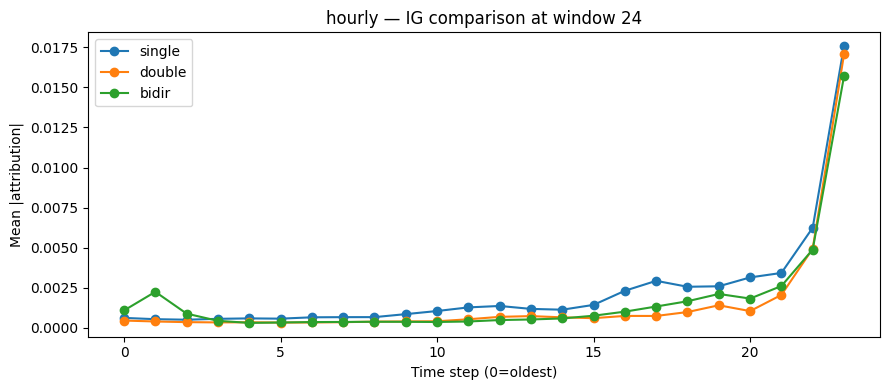

Saved /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/behaviors/compare_ig_win24.png


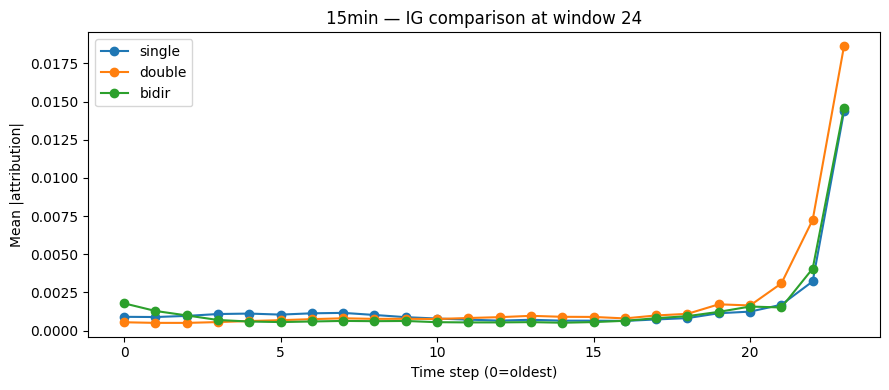

Saved /content/drive/MyDrive/Shared-Colab-Storage/Final/15min/behaviors/compare_ig_win24.png


In [9]:
for track, info in track_data.items():
    base = info["base"]
    window = COMPARE_WINDOW
    if window not in WINDOWS[track]:
        print(f"Skip compare for {track}: win{window} not in window list")
        continue

    plt.figure(figsize=(9, 4))
    found = 0
    for stack in STACKS:
        csv_path = f"{base}/behaviors/ig/{stack}/win{window}.csv"
        if not os.path.exists(csv_path):
            continue
        d = pd.read_csv(csv_path)
        plt.plot(d["step"], d["mean_abs_attr"], "o-", label=stack)
        found += 1

    if found == 0:
        plt.close()
        print(f"No IG files for {track} win{window} — run Part 2 first")
        continue

    plt.xlabel("Time step (0=oldest)")
    plt.ylabel("Mean |attribution|")
    plt.title(f"{track} — IG comparison at window {window}")
    plt.legend()
    plt.tight_layout()
    out = f"{base}/behaviors/compare_ig_win{window}.png"
    plt.savefig(out, dpi=120)
    plt.show()
    print("Saved", out)

---
# Part 6 — Hidden states (best model only)

**Question:** What does the LSTM's internal memory look like across many inputs?

**Method:** Pass training samples through the first LSTM layer, take the last hidden vector, plot with PCA.

**How to read:** Clusters in the scatter = the model groups similar situations internally (exploratory).

Hidden states hourly: best = double win24


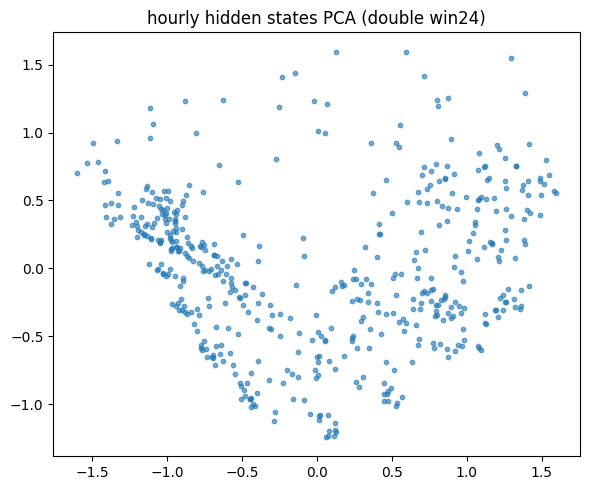

Saved /content/drive/MyDrive/Shared-Colab-Storage/Final/hourly/behaviors/hidden_states_pca.png
Hidden states 15min: best = single win96


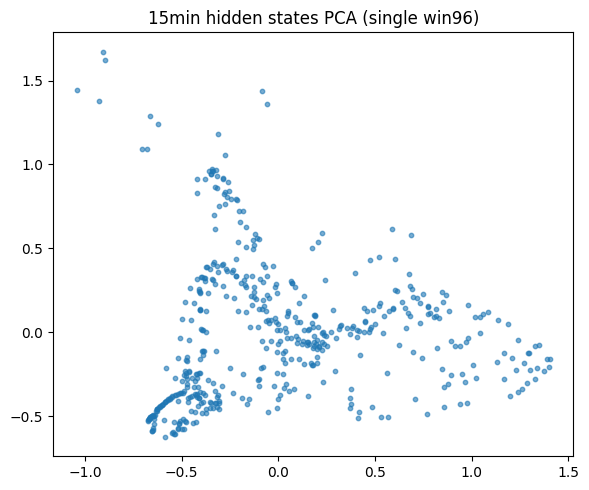

Saved /content/drive/MyDrive/Shared-Colab-Storage/Final/15min/behaviors/hidden_states_pca.png


In [10]:
for track, info in track_data.items():
    metrics_csv = f"{info['base']}/results_metrics.csv"
    if not os.path.exists(metrics_csv):
        print(f"Skip hidden states {track}: no results_metrics.csv")
        continue

    mdf = pd.read_csv(metrics_csv)
    col = "rmse_kwh" if "rmse_kwh" in mdf.columns else "rmse"
    best = mdf.loc[mdf[col].idxmin()]
    stack = str(best["model"])
    window = int(best["window"])
    model_path = f"{info['base']}/{stack}/models/win{window}.keras"
    if not os.path.exists(model_path):
        continue

    print(f"Hidden states {track}: best = {stack} win{window}")
    model = load_model(model_path, custom_objects={"rmse": rmse_metric})
    X_train, _, _, _ = build_windows(info["scaled_df"], info["feature_cols"], window, test_ratio)

    _ = model.predict(X_train[:1], verbose=0)
    sub = tf.keras.Model(inputs=model.inputs, outputs=model.layers[0].output)
    hs = sub.predict(X_train[:500], verbose=0)
    if hs.ndim == 3:
        hs = hs[:, -1, :]

    coords = PCA(n_components=2).fit_transform(hs)
    plt.figure(figsize=(6, 5))
    plt.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.6)
    plt.title(f"{track} hidden states PCA ({stack} win{window})")
    plt.tight_layout()
    out = f"{info['base']}/behaviors/hidden_states_pca.png"
    plt.savefig(out, dpi=120)
    plt.show()
    print("Saved", out)

---
## Done

Results on Drive under `Final/{track}/behaviors/`:

| Folder | Contents |
|--------|----------|
| `shap/` | Feature importance CSV + bar chart per model |
| `ig/` | Memory horizon CSV + line plot per model |
| `erasure/` | Memory erasure CSV + line plot per model |
| `fidelity/` | Fidelity CSV + bar chart per model |
| `compare_ig_win24.png` | Single vs double vs bidir overlay |
| `hidden_states_pca.png` | Best model internal states |

**For your report / presentation**, focus on hourly win24: compare the three IG curves and explain recency bias vs bidirectional U-shape.